# Segmentation

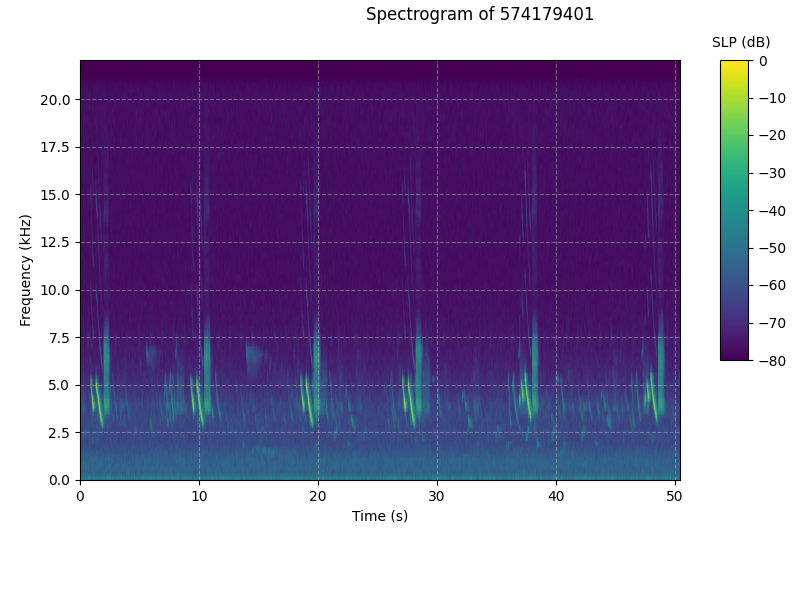

In [1]:
%matplotlib ipympl
from wavesongs.utils import plot
from wavesongs.object import Song, Syllable, Synthetic
from wavesongs.data.manager import ProjDirs

proj_dirs = ProjDirs(audios="./assets/audios", results="./experiments/")
ploter = plot.set_plotter(library="matplotlib", save_dir=str(proj_dirs.images))

copeton_record = Song(file_id="574179401")
copeton_record.acoustical_features(umbral_FF=1.4, n_fft=256)
_ = ploter.spectrogram(copeton_record)

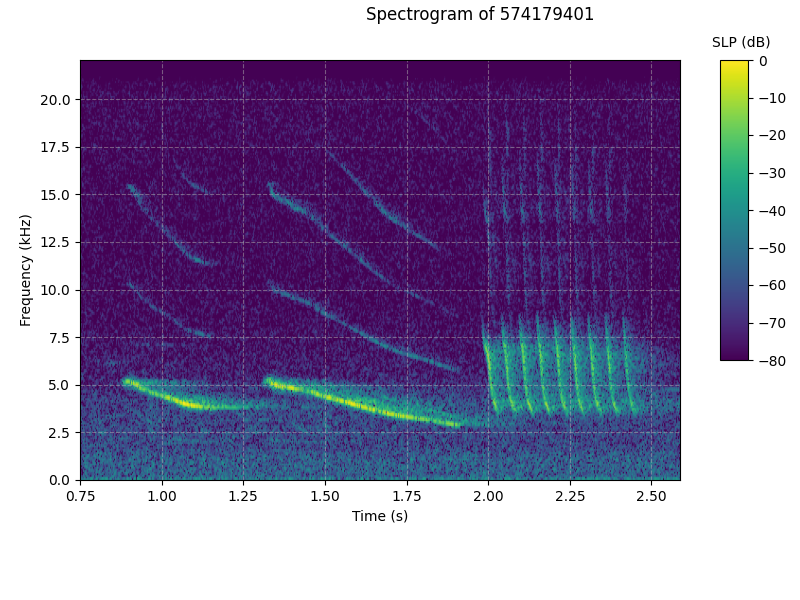

In [2]:
copeton_bs = Syllable(file_id="574179401", tlim=(0.75, 2.6))
copeton_bs.acoustical_features(umbral_FF=1., n_fft=512)

_ = ploter.spectrogram(copeton_bs)#, ylim=(0, 0.5))

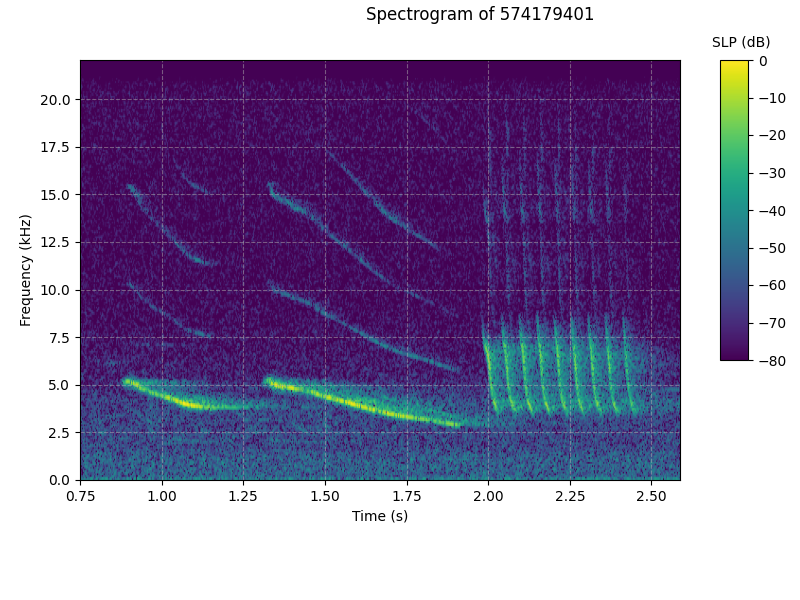

In [3]:
_ = ploter.spectrogram(copeton_bs)#, ylim=(0, 0.5))

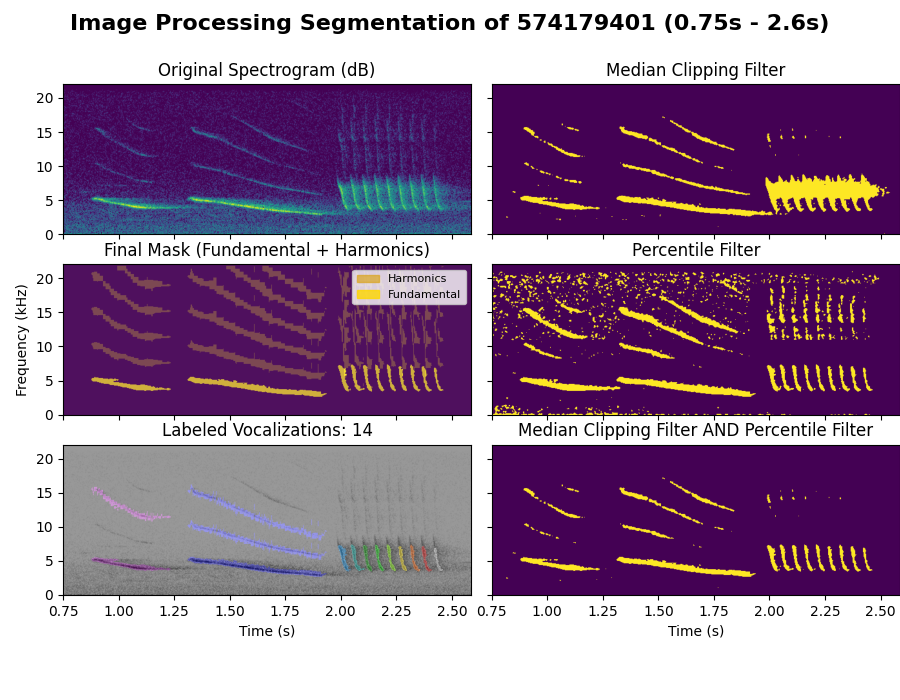

In [4]:
copeton_bs.segmentation(
    mode= "signal_pro", #"region_growing",#
    # threshold_1=0.1, threshold_2=0.8, min_duration= 0.03,
    img_pro_params={
        "scalar": 3,
        "threshold": 1e-6,
        # "pref": 34,  # dB
        "percentile": 80,
        "sigma": 1.0,
        "window_params": {"W": 64, "h": 100},
        "min_area": 100, # pixels
        "min_duration": 9, # pixels
        
        "no_harmonics": 6,
        "margin_pixels": 3,
        "times": 3,
        "ff_computing": "img_pro",  # "yin", "pyin", "img_pro"

        "closing": 3,
        "stride": 2, 
        
    },
)
# copeton.segments, copeton.segments_time
# Plotly().spectrogram(copeton, type="2d", auxiliar="none", mode="max", waveforme=True)

_ = ploter.segmentation( # #
    copeton_bs,
    harmonics=False,
    fundamental=False,
    alpha=0.9,
    grid=False,
    colorbar=False,
    filters=True,
    figsize=(9, 7),
    label="syllables" # "segments"
)
# copeton.segments_time, #, copeton.segments_Sxx

In [ ]:
syllables_list = [
    copeton_record.regions[region]
    for region in copeton_record.regions
    if copeton_record.regions[region][0]["id"] == "fundamental"
]
syllable_times = {
    syllable[0]["syllable_label"]: (syllable[0]["t_ini"], syllable[0]["t_end"])
    for syllable in syllables_list
}
syllable_times

{1: (np.float64(0.8809070294784581), np.float64(1.2770975056689342)),
 2: (np.float64(1.3119274376417234), np.float64(1.943219954648526)),
 3: (np.float64(1.9882086167800452), np.float64(2.0404535147392293)),
 4: (np.float64(2.0477097505668937), np.float64(2.1086621315192744)),
 5: (np.float64(2.10140589569161), np.float64(2.162358276643991)),
 6: (np.float64(2.1565532879818594), np.float64(2.1986394557823132)),
 7: (np.float64(2.2087981859410433), np.float64(2.2552380952380955)),
 8: (np.float64(2.261043083900227), np.float64(2.366984126984127)),
 9: (np.float64(2.3655328798185944), np.float64(2.426485260770975)),
 10: (np.float64(2.420680272108844), np.float64(2.46421768707483)),
 11: (np.float64(5.566984126984127), np.float64(5.659863945578231)),
 12: (np.float64(7.100952380952381), np.float64(7.15609977324263)),
 13: (np.float64(7.170612244897959), np.float64(7.205442176870749)),
 14: (np.float64(7.21124716553288), np.float64(7.288163265306123)),
 15: (np.float64(7.3244444444444445

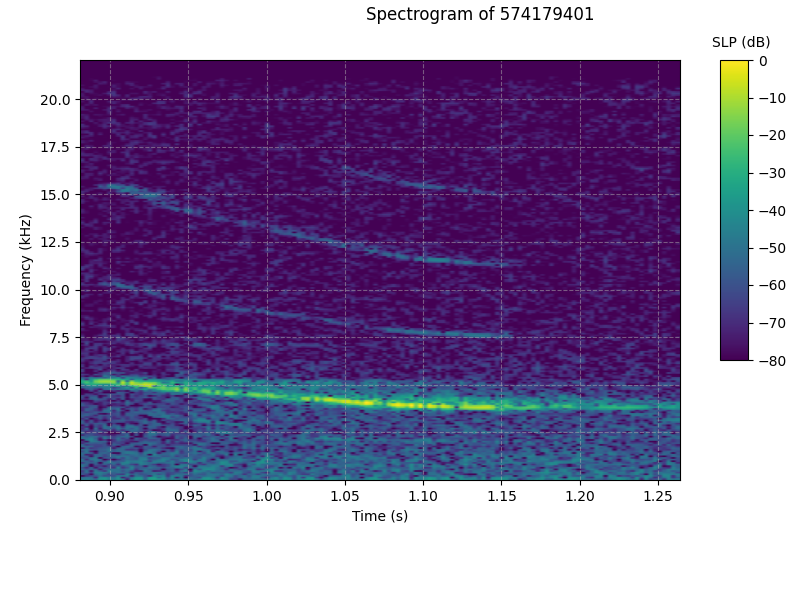

In [73]:
copeton_bs = Syllable(file_id="574179401", tlim=syllable_times[1])
copeton_bs.acoustical_features(umbral_FF=1., n_fft=512)

_ = ploter.spectrogram(copeton_bs)#, ylim=(0, 0.5))

# Grid Parameter Space

4410


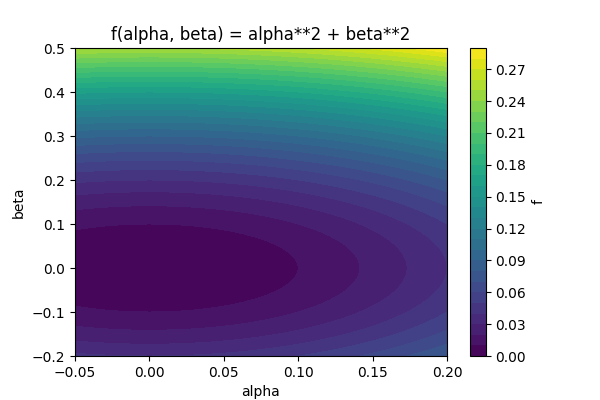

In [112]:
import numpy as np
import matplotlib.pyplot as plt

sr=44100
duration = 0.1
N = int(sr * duration)
print(N)

alpha = np.linspace(-0.05, 0.2, N)
beta = np.linspace(-0.2, 0.5, N)
alpha_grid, beta_grid = np.meshgrid(alpha, beta)

def f(alpha_vals, beta_vals):
    return alpha_vals**2 + beta_vals**2

z = f(alpha_grid, beta_grid)

fig, ax = plt.subplots(figsize=(6, 4))
contour = ax.contourf(alpha_grid, beta_grid, z, levels=30, cmap="viridis")
ax.set_xlabel("alpha")
ax.set_ylabel("beta")
ax.set_title("f(alpha, beta) = alpha**2 + beta**2")
fig.colorbar(contour, ax=ax, label="f")
plt.show()

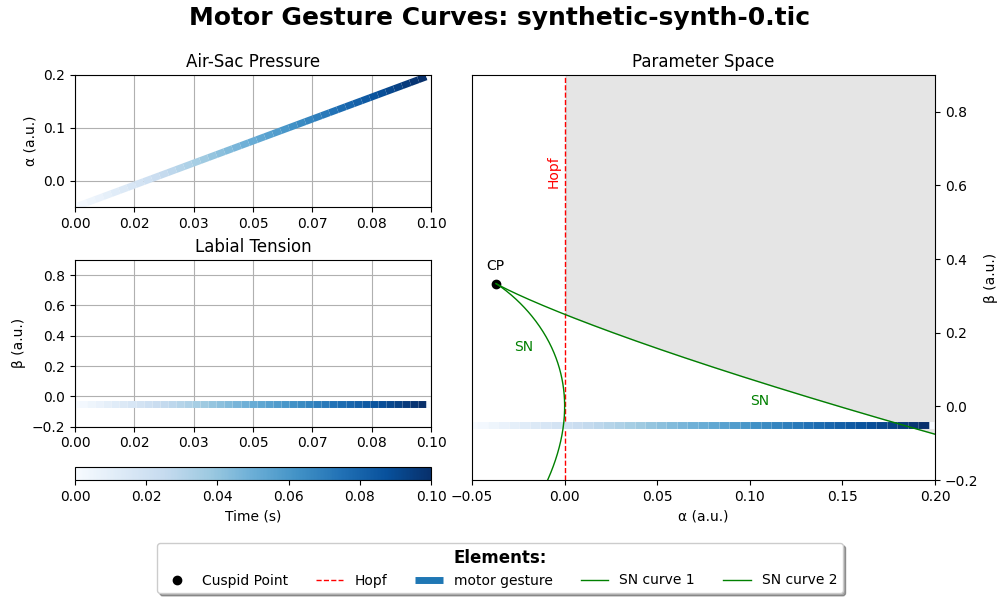

In [110]:
_ = ploter.alpha_beta(synthetized, save=False)

In [115]:
import os
from concurrent.futures import ProcessPoolExecutor

from wavesongs.core.bird import Model

def run_one(alpha_curve, beta_curve, duration, proj_dirs, sr):
    # Create a fresh synthetic object and model inside the worker process
    btv_synth = Synthetic(duration=duration, proj_dirs=proj_dirs, sr=sr)
    btv_synth.initialize()
    model = Model()
    # Run the motor gesture and compute acoustical features
    synthetized = model.motor_gesture(btv_synth, curves=[alpha_curve, beta_curve])
    synthetized.acoustical_features(umbral_FF=1.0, n_fft=512, ff_method="yin")
    # Return the features we want to collect
    return synthetized.SCI, synthetized.ff

# Prepare inputs for each grid index
inputs = []
for i in range(len(alpha_grid)):
    beta_curve = alpha_grid[:, i]
    alpha_curve = alpha_grid[i, :]
    inputs.append((alpha_curve, beta_curve))

# Run in parallel across CPU cores (leave one core free)
n_jobs = max(1, (os.cpu_count() or 2) - 1)
sci_list = []
f0_list = []
with ProcessPoolExecutor(max_workers=n_jobs) as executor:
    results = executor.map(
        run_one,
        (alpha for alpha, _ in inputs),
        (beta for _, beta in inputs),
        (duration for _ in inputs),
        (proj_dirs for _ in inputs),
        (sr for _ in inputs),
    )
    for sci, f0 in results:
        sci_list.append(sci)
        f0_list.append(f0)

KeyboardInterrupt: 

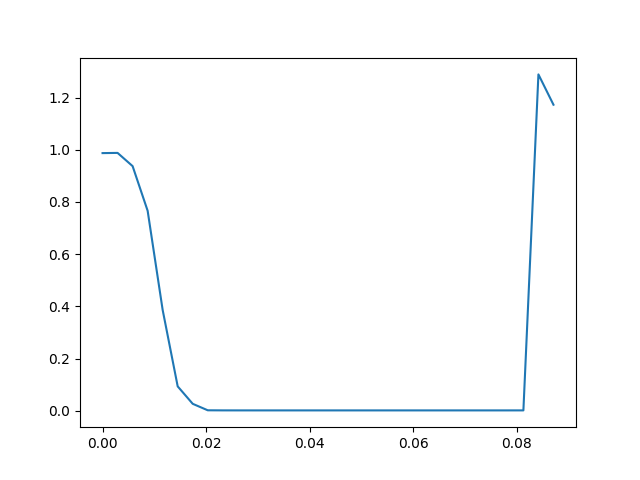

In [109]:
synthetized.SCI.shape, synthetized.ff.shape, synthetized.time.shape

plt.figure()
plt.plot(synthetized.time, synthetized.SCI)
plt.show()

In [4]:
from wavesongs.data.manager import ProjDirs

proj_dirs = ProjDirs(audios="/home/saguileran/Documentos/datasets",# "../assets/audios",
                     results="../assets/results")
proj_dirs.find_audios(pretty=False) # Check files pin the audio directory

# %%
# Syllable definition
# -------------------
# The `Syllable` class is used to define a syllable from an audio file.
# It requires the file ID and the time limits for the syllable.
# The `proj_dirs` argument is used to specify the directories for audio files and results.
from wavesongs.object import Syllable

filed_id = proj_dirs.files_names[0]
copeton_1 = Syllable(file_id=filed_id, tlim=(16.1, 18.2), proj_dirs=proj_dirs)
# %%
# The `Syllable` object can be used to access various properties of the syllable,
# such as the audio file, time limits, and other attributes.
copeton_1.acoustical_features(umbral_FF=1.4, n_fft=512)

# %%
# Visualization
# -------------
# The `set_plotter` function is used to set the plotting backend.
# In this case, we are using Plotly for visualization.
# The `spectrogram` method of the `Syllable` class is used to plot the spectrogram of the syllable.
# The `type` parameter can be set to "2d" or "3d" for different visualizations.
from wavesongs.utils.plot import set_plotter

plotter = set_plotter("plotly")
# fig = plotter.spectrogram(copeton_1, type="3d")
# fig
# %%
# Spectrogram
# -----------
_ = plotter.spectrogram(copeton_1, type="2d", auxiliar="none",
                        mode="max", waveforme=False, grid=True, ff=False)
                        
